In [6]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import medmnist
import pandas as pd
from medmnist import INFO, Evaluator

In [1]:
!pip install medmnist
import re

with open("/kaggle/input/datasets/majdoubnourelhouda/indices-corset/indices..txt", "r") as f:
    text = f.read()

# Remove np.int64(...) wrapper
text = re.sub(r"np\.int64\((\d+)\)", r"\1", text)

# Convert string → list
indices = eval(text)

# Ensure all are ints
indices = [int(x) for x in indices]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 2.4 MB/s eta 0:00:00a 0:00:01


In [4]:
print(len(indices),max(indices),min(indices))

2000 39965 5


## get the entire chestmnist ds

In [7]:
data_flag = 'chestmnist'
# data_flag = 'breastmnist'
download = True


info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])
# preprocessing
data_transform = transforms.Compose([
      #  transforms.Resize(224),
#cause resnet workswith 224 224  but teh images are 2828  so ths so the feautres are more meaninguly
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
from torch.utils.data import ConcatDataset

train_dataset = DataClass(split='train', transform=data_transform, download=True)
val_dataset = DataClass(split='val', transform=data_transform, download=True)
test_dataset = DataClass(split='test', transform=data_transform, download=True)

corpus = ConcatDataset([train_dataset, val_dataset, test_dataset])
X = []
Y = []

for img, label in corpus:
    X.append(img.numpy())
    Y.append(label)

X= np.array(X)
Y = np.array(Y)

100%|██████████| 82.8M/82.8M [00:05<00:00, 14.0MB/s]


In [9]:
print(n_classes ,info['label'])

14 {'0': 'atelectasis', '1': 'cardiomegaly', '2': 'effusion', '3': 'infiltration', '4': 'mass', '5': 'nodule', '6': 'pneumonia', '7': 'pneumothorax', '8': 'consolidation', '9': 'edema', '10': 'emphysema', '11': 'fibrosis', '12': 'pleural', '13': 'hernia'}


# to extract your corset from the entire ds , using indexes

In [8]:
X_coreset = X[indices]
Y_coreset = Y[indices] 

In [12]:
#sanity check 
print((Y_coreset == Y[indices]).all())

True


In [14]:
#your labels must be one hot labels encded
Y_coreset[3]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [13]:
#per disease freq not class dis
print(np.sum(Y[:40000], axis=0))         # full dataset
print(np.sum(Y_coreset, axis=0))  # coreset
print("----------")
print(np.sum(Y[:40000], axis=0)/40000 )         # full dataset
print(np.sum(Y_coreset, axis=0)/len(Y_coreset))  # coreset

[4025  989 4704 7011 2069 2271  505 1874 1640  855  881  592 1173   80]
[194  50 199 342  83 101  24  86  78  38  45  24  47   2]
----------
[0.100625 0.024725 0.1176   0.175275 0.051725 0.056775 0.012625 0.04685
 0.041    0.021375 0.022025 0.0148   0.029325 0.002   ]
[0.097  0.025  0.0995 0.171  0.0415 0.0505 0.012  0.043  0.039  0.019
 0.0225 0.012  0.0235 0.001 ]


In [15]:
full_counts = np.sum(Y[:40000], axis=0)
core_counts = np.sum(Y_coreset, axis=0)

print(full_counts)
print(core_counts)

print("----------")

full_freq = full_counts / 40000
core_freq = core_counts / len(Y_coreset)

print(full_freq)
print(core_freq)

print("----------")

print("difference:", np.abs(full_freq - core_freq))

[4025  989 4704 7011 2069 2271  505 1874 1640  855  881  592 1173   80]
[194  50 199 342  83 101  24  86  78  38  45  24  47   2]
----------
[0.100625 0.024725 0.1176   0.175275 0.051725 0.056775 0.012625 0.04685
 0.041    0.021375 0.022025 0.0148   0.029325 0.002   ]
[0.097  0.025  0.0995 0.171  0.0415 0.0505 0.012  0.043  0.039  0.019
 0.0225 0.012  0.0235 0.001 ]
----------
difference: [0.003625 0.000275 0.0181   0.004275 0.010225 0.006275 0.000625 0.00385
 0.002    0.002375 0.000475 0.0028   0.005825 0.001   ]


In [33]:
from torch.utils.data import Subset

corset = Subset(corpus, indices)  #your corset with the indexes
training_corpus = Subset(corpus, list(range(40000)))


In [34]:
print(len(corset))
print(len(training_corpus))

2000
40000


## getting features of corpus and corset 

In [23]:
import torch
import torchvision.models as models
from torch.utils.data import DataLoader

model = models.resnet50(weights="DEFAULT")
model.fc = torch.nn.Identity()  # remove classifier
model.eval()
#X = X.reshape(len(X), -1)
loader = DataLoader(
    corset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 344MB/s]


In [39]:
print(len(training_corpus))

40000


In [40]:
#gettingthe embeddings of the corpus you trained on
loader2 = DataLoader(
    training_corpus, #! **
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
features_corpus = [] #! **
labels_corpus = [] #! **

with torch.no_grad():
    for imgs, lbls in loader2:  #! **
       # print("o")
        imgs = imgs.repeat(1,3,1,1)  # convert 1-channel -> 3-channel

        feats = model(imgs)          # batch forward pass
        features_corpus.append(feats.cpu())  #! **

        labels_corpus.append(lbls)  #! **

features_corpus = torch.cat(features_corpus).numpy() #! **
labels_corpus = torch.cat(labels_corpus).numpy() #! **

In [41]:
print(len(features_corpus),len(labels_corpus))

40000 40000


In [25]:
#gettting the labels ofthe corset
features_corset = []
labels_corset = []

with torch.no_grad():
    for imgs, lbls in loader:
       # print("o")
        imgs = imgs.repeat(1,3,1,1)  # convert 1-channel -> 3-channel

        feats = model(imgs)          # batch forward pass
        features_corset.append(feats.cpu())

        labels_corset.append(lbls)

features_corset = torch.cat(features_corset).numpy()
labels_corset = torch.cat(labels_corset).numpy()

In [26]:
print(len(features_corset),len(labels_corset))

2000 2000


# compare with random selection

In [29]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

############################################
# Helper functions
############################################

def representation_error(corpus, C):
    """
    Average distance from each datapoint to its closest coreset point
    """
    total = 0
    for i in range(len(corpus)):
        d = min(np.linalg.norm(corpus[i] - corpus[c]) for c in C)
        total += d
    return total / len(corpus)


def max_distance(corpus, C):
    """
    Worst represented datapoint
    """
    max_d = 0
    for i in range(len(corpus)):
        d = min(np.linalg.norm(corpus[i] - corpus[c]) for c in C)
        if d > max_d:
            max_d = d
    return max_d


def mean_difference(corpus, C):
    """
    Difference between dataset mean and coreset mean
    """
    dataset_mean = np.mean(corpus, axis=0)
    coreset_mean = np.mean(corpus[C], axis=0)

    return np.linalg.norm(dataset_mean - coreset_mean)


def covariance_difference(corpus, C):
    """
    Difference between dataset covariance and coreset covariance
    """
    cov_dataset = np.cov(corpus.T)
    cov_coreset = np.cov(corpus[C].T)

    return np.linalg.norm(cov_dataset - cov_coreset)


############################################
# Random baseline
############################################

def random_coreset(n_points, K):
    return np.random.choice(n_points, K, replace=False)


############################################
# Evaluation
############################################

def evaluate_coreset(features, coreset_indices):

    N = len(features)
    K = len(coreset_indices)

    print("Dataset size:", N)
    print("Coreset size:", K)

    # Random subset
    random_indices = random_coreset(N, K)

    print("\nComputing metrics...")

    ########################################
    # Representation error
    ########################################

    greedy_error = representation_error(features, coreset_indices)
    random_error = representation_error(features, random_indices)

    ########################################
    # Coverage
    ########################################

    greedy_max = max_distance(features, coreset_indices)
    random_max = max_distance(features, random_indices)

    ########################################
    # Distribution similarity
    ########################################

    greedy_mean_diff = mean_difference(features, coreset_indices)
    random_mean_diff = mean_difference(features, random_indices)

    greedy_cov_diff = covariance_difference(features, coreset_indices)
    random_cov_diff = covariance_difference(features, random_indices)

    ########################################
    # Print results
    ########################################

    print("\n===== Representation Error =====")
    print("Greedy coreset :", greedy_error)
    print("Random subset  :", random_error)

    print("\n===== Max Distance (coverage) =====")
    print("Greedy coreset :", greedy_max)
    print("Random subset  :", random_max)

    print("\n===== Mean Difference =====")
    print("Greedy coreset :", greedy_mean_diff)
    print("Random subset  :", random_mean_diff)

    print("\n===== Covariance Difference =====")
    print("Greedy coreset :", greedy_cov_diff)
    print("Random subset  :", random_cov_diff)

    ########################################
    # PCA Visualization
    ########################################

    print("\nRunning PCA visualization...")

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(features)

    plt.figure()

    plt.scatter(
        reduced[:,0],
        reduced[:,1],
        s=5,
        alpha=0.2,
        label="dataset"
    )

    plt.scatter(
        reduced[coreset_indices,0],
        reduced[coreset_indices,1],
        s=40,
        label="greedy coreset"
    )

    plt.scatter(
        reduced[random_indices,0],
        reduced[random_indices,1],
        s=40,
        marker="x",
        label="random subset"
    )

    plt.legend()
    plt.title("Coreset Coverage (PCA projection)")
    plt.show()

Dataset size: 40000
Coreset size: 2000

Computing metrics...

===== Representation Error =====
Greedy coreset : 34.596592
Random subset  : 36.726315

===== Max Distance (coverage) =====
Greedy coreset : 68.45219
Random subset  : 74.25488

===== Mean Difference =====
Greedy coreset : 2.6440792
Random subset  : 0.9418732

===== Covariance Difference =====
Greedy coreset : 72.65557462738899
Random subset  : 48.248690785857264

Running PCA visualization...


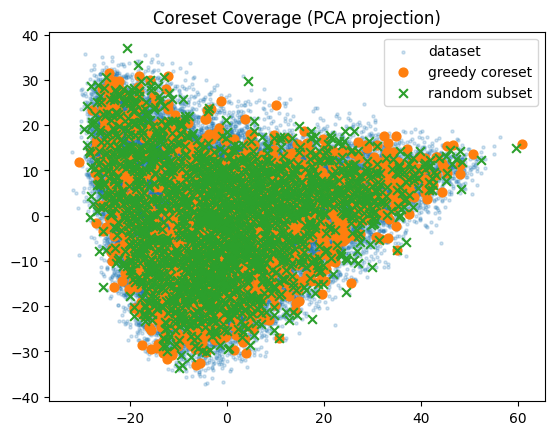

In [42]:
evaluate_coreset(features_corpus, indices)
#sac mean for coverage?

In [45]:
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=1)
nn.fit(features_corpus[indices])

distances, _ = nn.kneighbors(features_corpus)
print("Mean coverage distance:", distances.mean())
print("Max coverage distance:", distances.max())

Mean coverage distance: 34.596753654549424
Max coverage distance: 68.45218658447266


In [46]:
import numpy as np
from scipy.stats import wasserstein_distance, ks_2samp
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

def validate_coreset(corpus, coreset_indices, labels=None, n_pca_components=2):
    """
    Full validation suite for a coreset.
    
    Args:
        corpus: np.array of shape (N, D) — full embedding matrix
        coreset_indices: list of ints — indices selected by GreedyCoreset
        labels: optional np.array of shape (N,) — class labels
        n_pca_components: int — for visualization
    
    Returns:
        dict of validation metrics
    """
    
    coreset = corpus[coreset_indices]
    N = len(corpus)
    K = len(coreset_indices)
    
    metrics = {}
    
    # ── 1. Coverage: avg min-distance from each point to its nearest coreset point ──
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(coreset)
    dists, _ = nn.kneighbors(corpus)
    
    metrics['mean_coverage_dist'] = float(np.mean(dists))
    metrics['max_coverage_dist']  = float(np.max(dists))   # worst case uncovered point
    metrics['std_coverage_dist']  = float(np.std(dists))
    
    # ── 2. Distribution alignment: Wasserstein distance per PCA dimension ──
    pca = PCA(n_components=min(n_pca_components, corpus.shape[1]))
    full_pca    = pca.fit_transform(corpus)
    coreset_pca = pca.transform(coreset)
    
    wasserstein_per_dim = []
    ks_per_dim          = []
    for dim in range(full_pca.shape[1]):
        w = wasserstein_distance(full_pca[:, dim], coreset_pca[:, dim])
        _, ks_p = ks_2samp(full_pca[:, dim], coreset_pca[:, dim])
        wasserstein_per_dim.append(w)
        ks_per_dim.append(ks_p)
    
    metrics['wasserstein_per_pca_dim'] = wasserstein_per_dim
    metrics['ks_pvalue_per_pca_dim']   = ks_per_dim  # high p = distributions are similar
    metrics['mean_wasserstein']        = float(np.mean(wasserstein_per_dim))
    
    # ── 3. Mean and covariance alignment ──
    full_mean    = np.mean(corpus,  axis=0)
    coreset_mean = np.mean(coreset, axis=0)
    metrics['mean_shift_l2'] = float(np.linalg.norm(full_mean - coreset_mean))
    
    # Frobenius norm between covariance matrices (use PCA-reduced for speed)
    full_cov    = np.cov(full_pca.T)
    coreset_cov = np.cov(coreset_pca.T)
    metrics['covariance_frob_diff'] = float(np.linalg.norm(full_cov - coreset_cov, 'fro'))
    
    # ── 4. Class balance preservation (if labels provided) ──

    """
    ISSUE1 LABELS SHAPE FOR COUNTER TOFIX
    """
    if labels is not None:
        full_counts    = Counter(labels)   #your labels
        coreset_labels = labels[coreset_indices]
        coreset_counts = Counter(coreset_labels)
        
        all_classes = sorted(full_counts.keys())
        full_dist    = np.array([full_counts[c]    / N for c in all_classes])
        coreset_dist = np.array([coreset_counts.get(c, 0) / K for c in all_classes])
        
        metrics['class_distribution_full']    = {c: full_counts[c]/N    for c in all_classes}
        metrics['class_distribution_coreset'] = {c: coreset_counts.get(c,0)/K for c in all_classes}
        metrics['class_balance_tvd'] = float(0.5 * np.sum(np.abs(full_dist - coreset_dist)))
        # TVD = 0 means perfect match, TVD = 1 means completely different
    
    # ── 5. Redundancy: avg pairwise distance within coreset ──
    from sklearn.metrics import pairwise_distances
    if K <= 2000:  # skip for very large coresets
        coreset_pdists = pairwise_distances(coreset, metric='euclidean')
        np.fill_diagonal(coreset_pdists, np.nan)
        metrics['coreset_mean_pairwise_dist'] = float(np.nanmean(coreset_pdists))
    
    full_sample = corpus[np.random.choice(N, min(2000, N), replace=False)]
    full_pdists = pairwise_distances(full_sample, metric='euclidean')
    np.fill_diagonal(full_pdists, np.nan)
    metrics['full_mean_pairwise_dist'] = float(np.nanmean(full_pdists))
    
    return metrics


def plot_validation(corpus, coreset_indices, labels=None, label_names=None):
    """
    Visual validation dashboard.
    """
    
    coreset = corpus[coreset_indices]
    N, K    = len(corpus), len(coreset_indices)
    
    pca = PCA(n_components=2)
    full_pca    = pca.fit_transform(corpus)
    coreset_pca = pca.transform(coreset)
    
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
    
    # ── Plot 1: PCA scatter — full vs coreset ──
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.scatter(full_pca[:, 0], full_pca[:, 1],
                alpha=0.15, s=5, c='steelblue', label=f'Full dataset (n={N})')
    ax1.scatter(coreset_pca[:, 0], coreset_pca[:, 1],
                alpha=0.8,  s=20, c='crimson',   label=f'Coreset (k={K})',
                edgecolors='darkred', linewidths=0.4)
    ax1.set_title('PCA: full dataset vs coreset coverage')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.legend(fontsize=9)
    
    # ── Plot 2: Coverage distance distribution ──
    ax2 = fig.add_subplot(gs[0, 2])
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=1).fit(coreset)
    dists, _ = nn.kneighbors(corpus)
    ax2.hist(dists.flatten(), bins=50, color='steelblue', alpha=0.75, edgecolor='white')
    ax2.axvline(np.mean(dists), color='crimson', linestyle='--', linewidth=1.5,
                label=f'mean={np.mean(dists):.3f}')
    ax2.set_title('Coverage distance distribution')
    ax2.set_xlabel('Distance to nearest coreset point')
    ax2.set_ylabel('Count')
    ax2.legend(fontsize=9)
    
    # ── Plot 3: PC1 marginal distribution ──
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.hist(full_pca[:, 0],    bins=50, alpha=0.5, color='steelblue',
             density=True, label='Full')
    ax3.hist(coreset_pca[:, 0], bins=50, alpha=0.7, color='crimson',
             density=True, label='Coreset')
    ax3.set_title('PC1 distribution')
    ax3.set_xlabel('PC1 value')
    ax3.legend(fontsize=9)
    
    # ── Plot 4: PC2 marginal distribution ──
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.hist(full_pca[:, 1],    bins=50, alpha=0.5, color='steelblue',
             density=True, label='Full')
    ax4.hist(coreset_pca[:, 1], bins=50, alpha=0.7, color='crimson',
             density=True, label='Coreset')
    ax4.set_title('PC2 distribution')
    ax4.set_xlabel('PC2 value')
    ax4.legend(fontsize=9)
    
    # ── Plot 5: Class balance (if labels provided) ──
    ax5 = fig.add_subplot(gs[1, 2])
    if labels is not None:
        coreset_labels = labels[coreset_indices]
        classes        = sorted(np.unique(labels))
        names          = label_names if label_names else [str(c) for c in classes]
        
        full_freq    = [np.mean(labels == c)         for c in classes]
        coreset_freq = [np.mean(coreset_labels == c) for c in classes]
        
        x = np.arange(len(classes))
        w = 0.35
        ax5.bar(x - w/2, full_freq,    w, label='Full',    color='steelblue', alpha=0.8)
        ax5.bar(x + w/2, coreset_freq, w, label='Coreset', color='crimson',   alpha=0.8)
        ax5.set_xticks(x)
        ax5.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
        ax5.set_title('Class balance')
        ax5.set_ylabel('Proportion')
        ax5.legend(fontsize=9)
    else:
        ax5.text(0.5, 0.5, 'No labels provided',
                 ha='center', va='center', transform=ax5.transAxes,
                 color='gray', fontsize=11)
        ax5.set_title('Class balance')
    
    fig.suptitle(f'Coreset validation  |  K={K} / N={N}  ({100*K/N:.1f}%)',
                 fontsize=13, fontweight='bold')
    plt.savefig('coreset_validation.png', dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def print_validation_report(metrics):
    """Pretty-print the metrics dict."""
    
    print("=" * 55)
    print("  CORESET VALIDATION REPORT")
    print("=" * 55)
    
    print("\n[ Coverage ]")
    print(f"  Mean dist to nearest coreset point : {metrics['mean_coverage_dist']:.4f}")
    print(f"  Max  dist to nearest coreset point : {metrics['max_coverage_dist']:.4f}  ← worst-case gap")
    print(f"  Std  dist                          : {metrics['std_coverage_dist']:.4f}")
    
    print("\n[ Distribution alignment ]")
    print(f"  Mean Wasserstein (PCA dims)        : {metrics['mean_wasserstein']:.4f}  ← lower is better")
    for i, (w, p) in enumerate(zip(metrics['wasserstein_per_pca_dim'],
                                    metrics['ks_pvalue_per_pca_dim'])):
        flag = "OK" if p > 0.05 else "WARN"
        print(f"  PC{i+1}  W={w:.4f}  KS p={p:.3f}  [{flag}]")
    
    print("\n[ Centroid & spread ]")
    print(f"  Mean shift L2                      : {metrics['mean_shift_l2']:.4f}  ← should be near 0")
    print(f"  Covariance Frobenius diff          : {metrics['covariance_frob_diff']:.4f}")
    
    if 'class_balance_tvd' in metrics:
        print("\n[ Class balance ]")
        print(f"  Total variation distance           : {metrics['class_balance_tvd']:.4f}  ← 0=perfect, 1=worst")
        print(f"  {'Class':<15} {'Full':>8} {'Coreset':>10}")
        print(f"  {'-'*35}")
        for c in metrics['class_distribution_full']:
            f = metrics['class_distribution_full'][c]
            cs = metrics['class_distribution_coreset'].get(c, 0.0)
            flag = " !" if abs(f - cs) > 0.05 else ""
            print(f"  {str(c):<15} {f:>8.3f} {cs:>10.3f}{flag}")
    
    if 'coreset_mean_pairwise_dist' in metrics:
        print("\n[ Diversity ]")
        print(f"  Coreset mean pairwise dist         : {metrics['coreset_mean_pairwise_dist']:.4f}")
        print(f"  Full data mean pairwise dist       : {metrics['full_mean_pairwise_dist']:.4f}")
        ratio = metrics['coreset_mean_pairwise_dist'] / metrics['full_mean_pairwise_dist']
        print(f"  Ratio (coreset/full)               : {ratio:.3f}  ← >1 means diverse, <1 means clustered")
    
    print("=" * 55)

In [50]:

# Run validation
metrics = validate_coreset(features_corpus, indices, labels=None, n_pca_components=2)
print_validation_report(metrics)

# Visual dashboard


  CORESET VALIDATION REPORT

[ Coverage ]
  Mean dist to nearest coreset point : 34.5968
  Max  dist to nearest coreset point : 68.4522  ← worst-case gap
  Std  dist                          : 9.9381

[ Distribution alignment ]
  Mean Wasserstein (PCA dims)        : 1.4159  ← lower is better
  PC1  W=1.4141  KS p=0.000  [WARN]
  PC2  W=1.4178  KS p=0.000  [WARN]

[ Centroid & spread ]
  Mean shift L2                      : 2.6441  ← should be near 0
  Covariance Frobenius diff          : 30.2876

[ Diversity ]
  Coreset mean pairwise dist         : 64.6015
  Full data mean pairwise dist       : 66.0505
  Ratio (coreset/full)               : 0.978  ← >1 means diverse, <1 means clustered


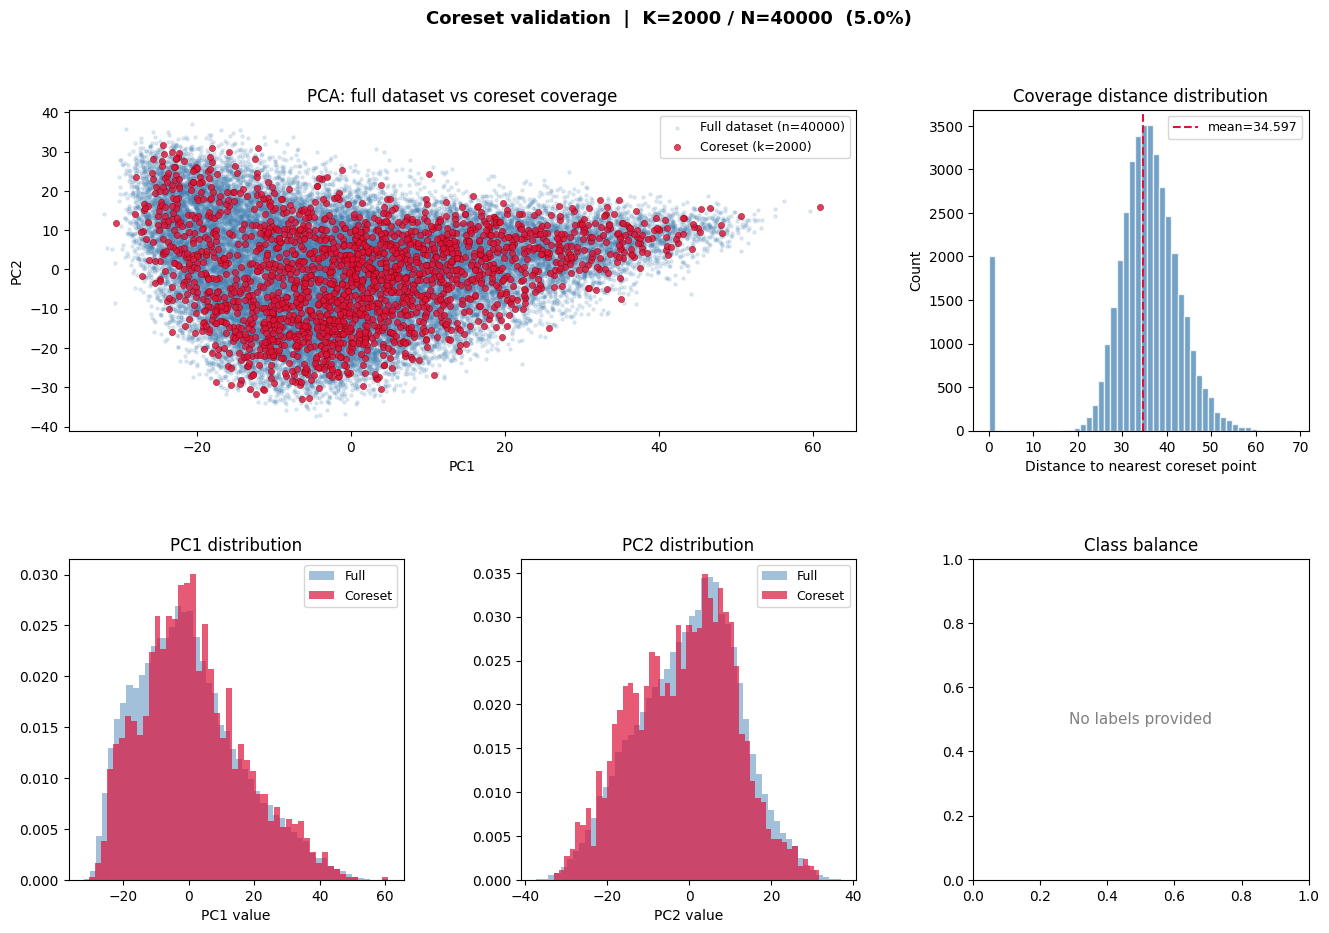

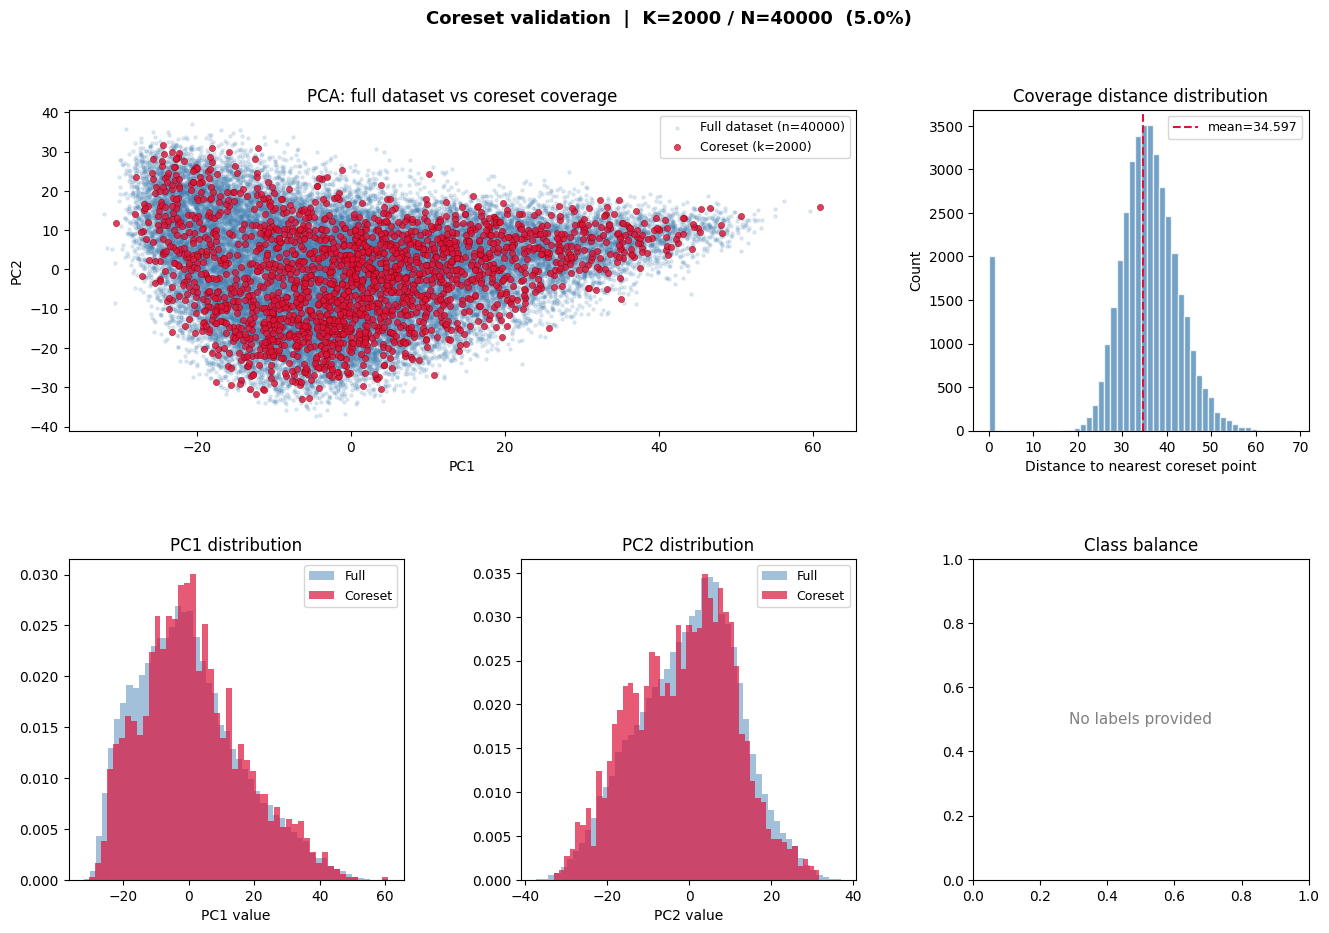

In [51]:
chestmnist_labels = ['Atelectasis','Cardiomegaly','Effusion','Infiltration',
                     'Mass','Nodule','Pneumonia','Pneumothorax']
plot_validation(features_corpus, indices, labels=None, label_names=None)